 # Matplotlib & Seaborn — Practical Guide

Quick reference for every plot type used in data science and ML.
Code examples are self-contained and copy-paste ready.

**Sections:**
1. Setup & Figure anatomy
2. Line plot
3. Scatter plot
4. Bar chart
5. Histogram + KDE
6. Box & Violin plot
7. Subplots layout
8. Styling — colors, markers, linestyles
9. Titles, labels, legend, grid, spines
10. Saving figures
11. Seaborn quick reference
12. ML-specific plots (confusion matrix, ROC, learning curve, feature importance, heatmap)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris

# Shared data
rng = np.random.default_rng(42)
x   = np.linspace(0, 2*np.pi, 100)

iris = load_iris(as_frame=True)
df_iris = iris.data.copy()
df_iris['species'] = iris.target_names[iris.target]

cancer = load_breast_cancer(as_frame=True)
X_c, y_c = cancer.data, cancer.target

print('Setup complete — all datasets loaded.')


Setup complete — all datasets loaded.


---
## 1. Figure Anatomy

Every matplotlib figure consists of:
- **Figure** — the outer canvas (`plt.figure()`)
- **Axes** — a single plot panel (`fig.add_subplot()` or `plt.subplots()`)
- **Artist** — everything drawn: lines, text, ticks, patches

Always use `fig, ax = plt.subplots()` — it gives you explicit control over each panel.

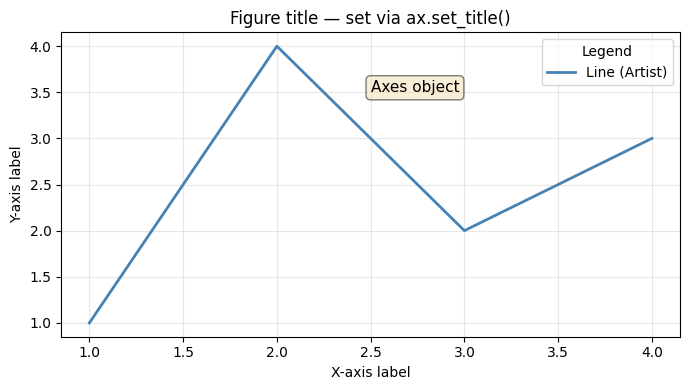

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))

# Annotate the anatomy
ax.plot([1, 2, 3, 4], [1, 4, 2, 3], color='steelblue', linewidth=2, label='Line (Artist)')
ax.set_title('Figure title — set via ax.set_title()')
ax.set_xlabel('X-axis label')
ax.set_ylabel('Y-axis label')
ax.legend(title='Legend')
ax.grid(True, alpha=0.3)

# Add text annotations
ax.annotate('Axes object', xy=(2.5, 3.5), fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()   # prevents label clipping
plt.show()


---
## 2. Line Plot

Best for: time series, curves, training loss, anything with order.

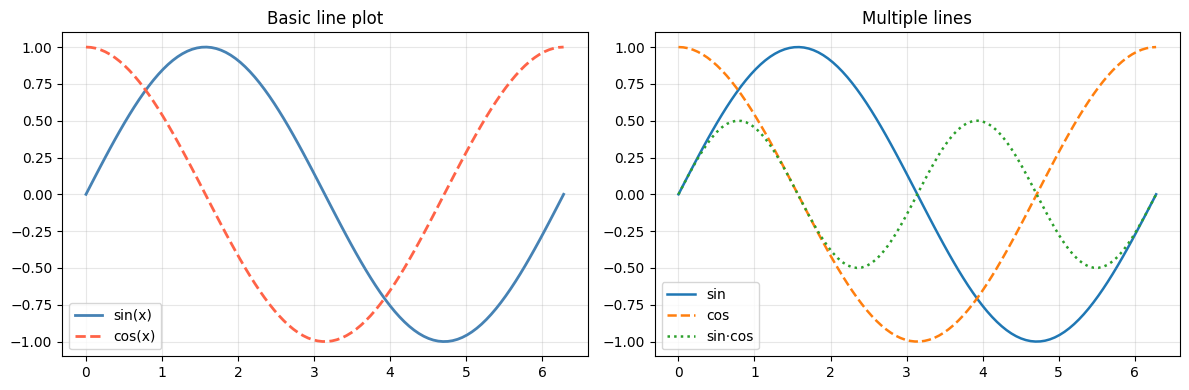

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Basic
axes[0].plot(x, np.sin(x), label='sin(x)', color='steelblue', linewidth=2)
axes[0].plot(x, np.cos(x), label='cos(x)', color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Basic line plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Multiple styles at once
for func, label, style in [(np.sin, 'sin', '-'),
                             (np.cos, 'cos', '--'),
                             (lambda x: np.sin(x)*np.cos(x), 'sin·cos', ':')]:
    axes[1].plot(x, func(x), label=label, linestyle=style, linewidth=1.8)
axes[1].set_title('Multiple lines')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 3. Scatter Plot

Best for: relationships between two variables, clusters, outliers.

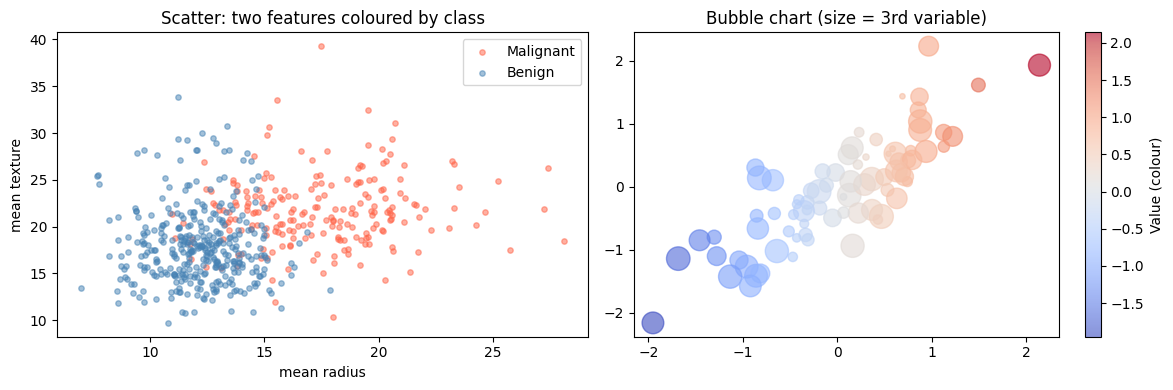

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Basic scatter — color by class
for cls, color, label in [(0,'tomato','Malignant'),(1,'steelblue','Benign')]:
    mask = y_c == cls
    axes[0].scatter(X_c.values[mask, 0], X_c.values[mask, 1],
                    c=color, label=label, alpha=0.5, s=15)
axes[0].set_xlabel(cancer.feature_names[0])
axes[0].set_ylabel(cancer.feature_names[1])
axes[0].set_title('Scatter: two features coloured by class')
axes[0].legend()

# Bubble chart — size encodes a 3rd variable
n = 80
x_b = rng.normal(0, 1, n)
y_b = x_b * 0.8 + rng.normal(0, 0.5, n)
sizes = (rng.uniform(10, 300, n))
sc = axes[1].scatter(x_b, y_b, c=x_b, cmap='coolwarm', s=sizes, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='Value (colour)')
axes[1].set_title('Bubble chart (size = 3rd variable)')

plt.tight_layout()
plt.show()


---
## 4. Bar Chart

Best for: comparing discrete categories.

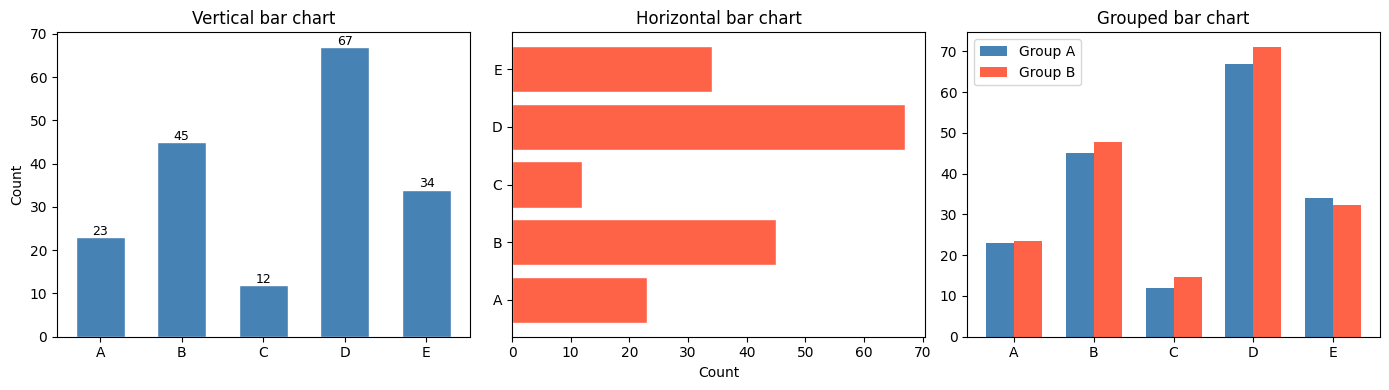

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Vertical bar
categories = ['A', 'B', 'C', 'D', 'E']
values     = [23, 45, 12, 67, 34]
axes[0].bar(categories, values, color='steelblue', edgecolor='white', width=0.6)
axes[0].set_title('Vertical bar chart')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=9)

# Horizontal bar
axes[1].barh(categories, values, color='tomato', edgecolor='white')
axes[1].set_title('Horizontal bar chart')
axes[1].set_xlabel('Count')

# Grouped bar
x_pos = np.arange(len(categories))
w = 0.35
v2 = [v * rng.uniform(0.7, 1.3) for v in values]
axes[2].bar(x_pos - w/2, values, width=w, label='Group A', color='steelblue')
axes[2].bar(x_pos + w/2, v2,     width=w, label='Group B', color='tomato')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(categories)
axes[2].set_title('Grouped bar chart')
axes[2].legend()

plt.tight_layout()
plt.show()


---
## 5. Histogram + KDE

Best for: distribution shape, skewness, outliers.

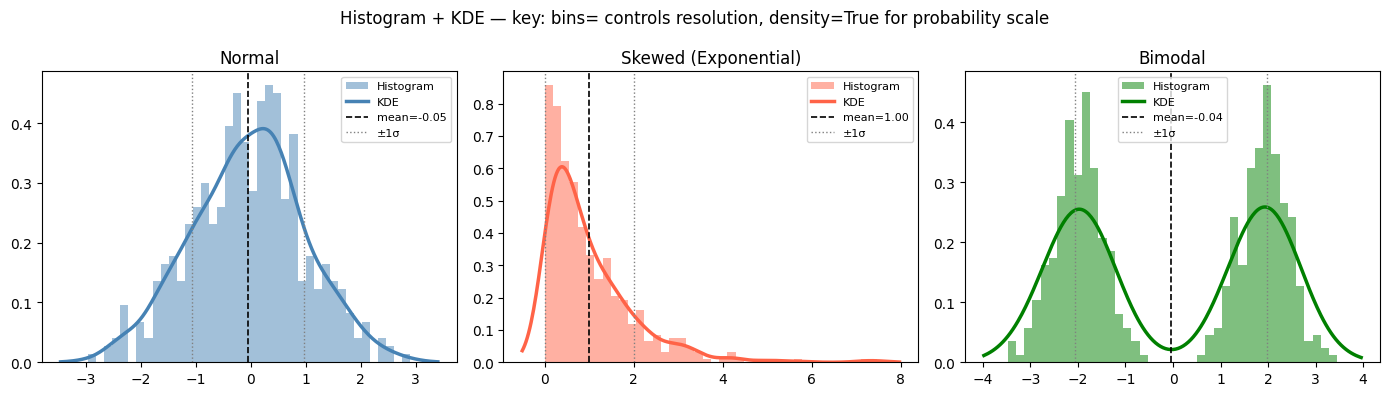

In [6]:
data_norm  = rng.normal(0, 1, 500)
data_skew  = rng.exponential(1, 500)
data_bimod = np.concatenate([rng.normal(-2,0.5,250), rng.normal(2,0.5,250)])
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title, color in zip(
        axes,
        [data_norm, data_skew, data_bimod],
        ['Normal', 'Skewed (Exponential)', 'Bimodal'],
        ['steelblue', 'tomato', 'green']):

    # Histogram (density=True → y-axis is density, not count)
    ax.hist(data, bins=40, density=True, alpha=0.5, color=color, label='Histogram')

    # KDE overlay
    xr = np.linspace(data.min()-0.5, data.max()+0.5, 300)
    kde = gaussian_kde(data)
    ax.plot(xr, kde(xr), color=color, linewidth=2.5, label='KDE')

    # Add mean and ±1 std lines
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2, label=f'mean={data.mean():.2f}')
    ax.axvline(data.mean()+data.std(), color='gray', linestyle=':', linewidth=1)
    ax.axvline(data.mean()-data.std(), color='gray', linestyle=':', linewidth=1, label='±1σ')

    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Histogram + KDE — key: bins= controls resolution, density=True for probability scale')
plt.tight_layout()
plt.show()


---
## 6. Box Plot & Violin Plot

Box plot reads:
```
  |—— whisker (1.5 × IQR)
  ┌────┐
  │    │  ← IQR (Q1–Q3)
  │ ─── │  ← median
  └────┘
  |—— lower whisker
  ●  ← outlier
```
Violin adds the distribution shape on top.

/tmp/ipykernel_49178/1546014382.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_by_species, labels=iris.target_names,
/tmp/ipykernel_49178/1546014382.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_iris, x='species', y='sepal length (cm)',


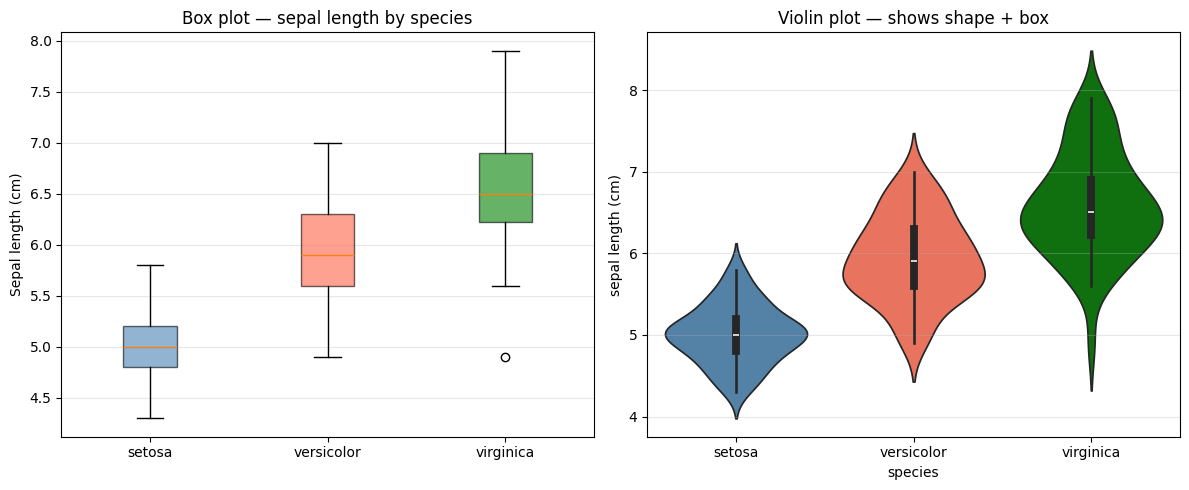

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot — one per species
data_by_species = [df_iris[df_iris['species']==sp]['sepal length (cm)'].values
                   for sp in iris.target_names]

bp = axes[0].boxplot(data_by_species, labels=iris.target_names,
                      patch_artist=True, notch=False)
colors = ['steelblue', 'tomato', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('Box plot — sepal length by species')
axes[0].set_ylabel('Sepal length (cm)')
axes[0].grid(True, axis='y', alpha=0.3)

# Violin plot (seaborn makes this easier)
sns.violinplot(data=df_iris, x='species', y='sepal length (cm)',
               palette=['steelblue','tomato','green'], ax=axes[1], inner='box')
axes[1].set_title('Violin plot — shows shape + box')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Subplots Layout

Use `plt.subplots(rows, cols)` for grids. Use `gridspec` for complex layouts.

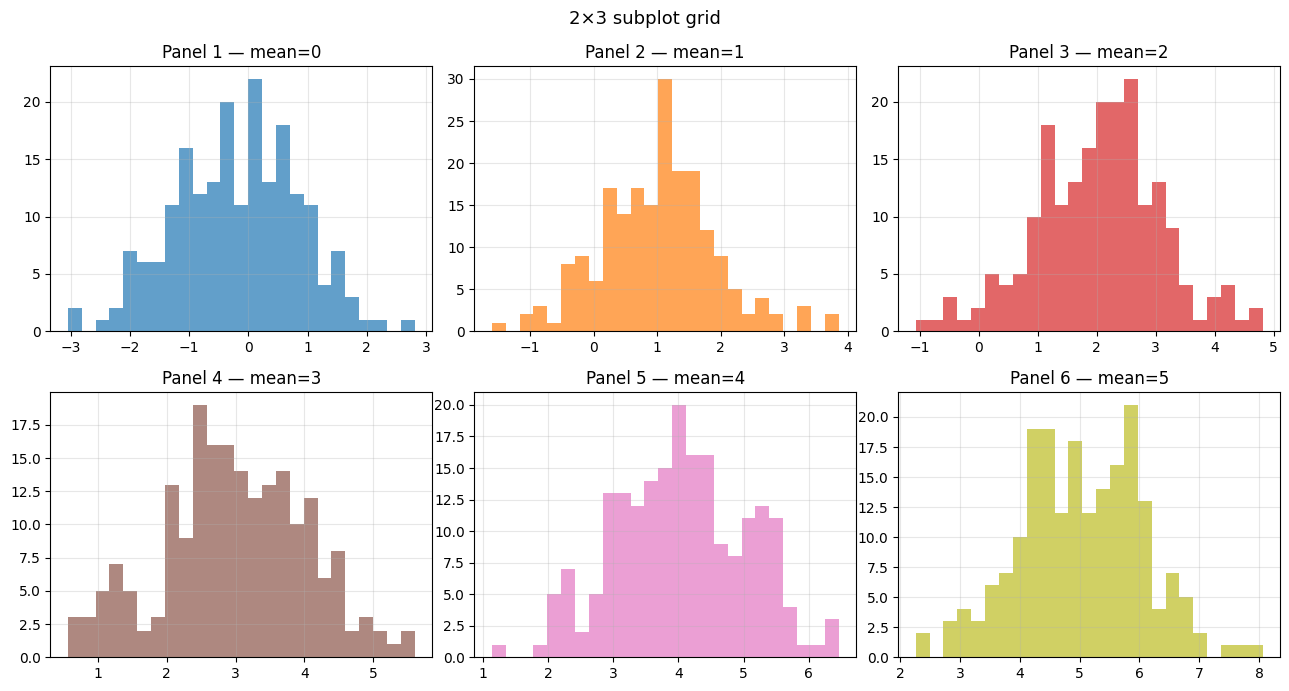

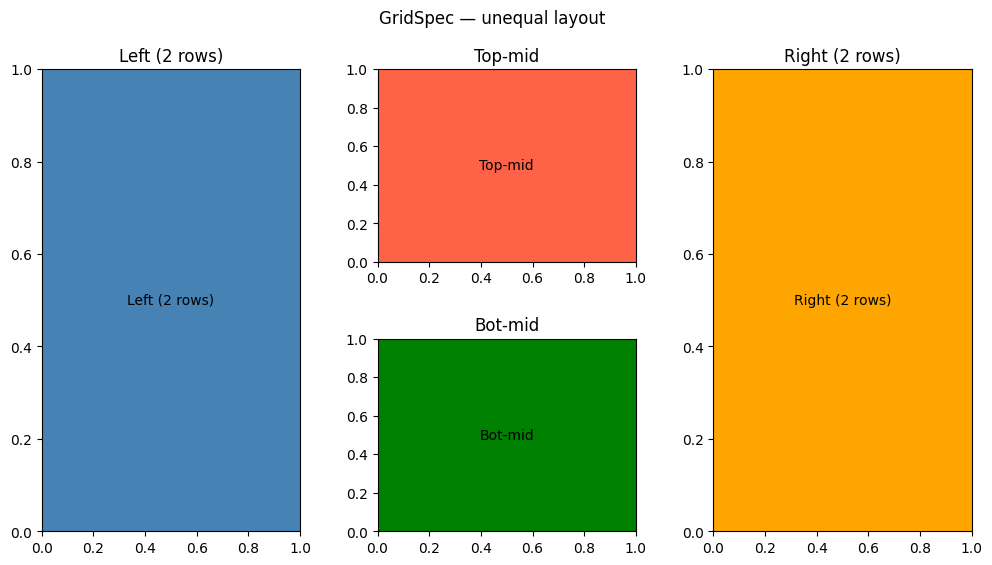

In [8]:
# ── Regular grid ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()   # flatten to 1-D for easy iteration

for i, ax in enumerate(axes):
    data = rng.normal(i, 1, 200)
    ax.hist(data, bins=25, color=plt.cm.tab10(i/6), alpha=0.7)
    ax.set_title(f'Panel {i+1} — mean={i}')
    ax.grid(True, alpha=0.3)

plt.suptitle('2×3 subplot grid', fontsize=13)
plt.tight_layout()
plt.show()

# ── Unequal grid with gridspec ────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 6))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

ax_big  = fig.add_subplot(gs[:, 0])    # full left column
ax_tr   = fig.add_subplot(gs[0, 1])
ax_br   = fig.add_subplot(gs[1, 1])
ax_wide = fig.add_subplot(gs[:, 2])    # full right column

for ax, title, color in [
        (ax_big,  'Left (2 rows)', 'steelblue'),
        (ax_tr,   'Top-mid',       'tomato'),
        (ax_br,   'Bot-mid',       'green'),
        (ax_wide, 'Right (2 rows)','orange')]:
    ax.set_facecolor(color)
    ax.set_alpha(0.3)
    ax.text(0.5, 0.5, title, ha='center', va='center', transform=ax.transAxes, fontsize=10)
    ax.set_title(title)

plt.suptitle('GridSpec — unequal layout', fontsize=12)
plt.show()


---
## 8. Styling Reference — Colors, Markers, Linestyles

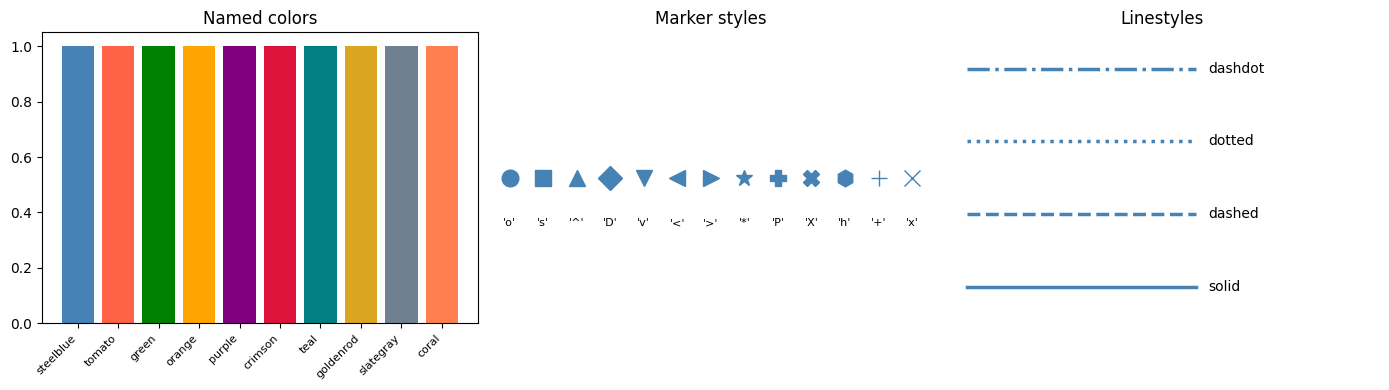

Useful colormaps:
  Sequential:  viridis, plasma, Blues, Reds, Greens, YlOrRd
  Diverging:   coolwarm, RdBu, seismic  (center at 0)
  Qualitative: tab10, tab20, Set1, Set2  (for categories)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Named colors ──────────────────────────────────────────────────────────────
named = ['steelblue','tomato','green','orange','purple',
         'crimson','teal','goldenrod','slategray','coral']
for i, c in enumerate(named):
    axes[0].bar(i, 1, color=c, label=c)
axes[0].set_xticks(range(len(named)))
axes[0].set_xticklabels(named, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Named colors')

# ── Markers ───────────────────────────────────────────────────────────────────
markers = ['o','s','^','D','v','<','>','*','P','X','h','+','x']
for i, m in enumerate(markers):
    axes[1].plot(i, 0, marker=m, markersize=12, linestyle='None',
                 label=repr(m), color='steelblue')
    axes[1].text(i, -0.1, repr(m), ha='center', fontsize=8)
axes[1].set_xlim(-0.5, len(markers)-0.5)
axes[1].set_ylim(-0.3, 0.3)
axes[1].set_title('Marker styles')
axes[1].axis('off')

# ── Linestyles ────────────────────────────────────────────────────────────────
styles = [('-','solid'),('--','dashed'),(':','dotted'),('-.','dashdot')]
for i, (ls, name) in enumerate(styles):
    axes[2].plot([0, 1], [i, i], linestyle=ls, linewidth=2.5,
                 color='steelblue', label=name)
    axes[2].text(1.05, i, name, va='center', fontsize=10)
axes[2].set_xlim(-0.1, 1.8)
axes[2].set_ylim(-0.5, len(styles)-0.5)
axes[2].set_title('Linestyles')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ── Colormaps ─────────────────────────────────────────────────────────────────
print('Useful colormaps:')
print('  Sequential:  viridis, plasma, Blues, Reds, Greens, YlOrRd')
print('  Diverging:   coolwarm, RdBu, seismic  (center at 0)')
print('  Qualitative: tab10, tab20, Set1, Set2  (for categories)')


---
## 9. Titles, Labels, Legend, Grid, Spines

Full control over every text and axis element.

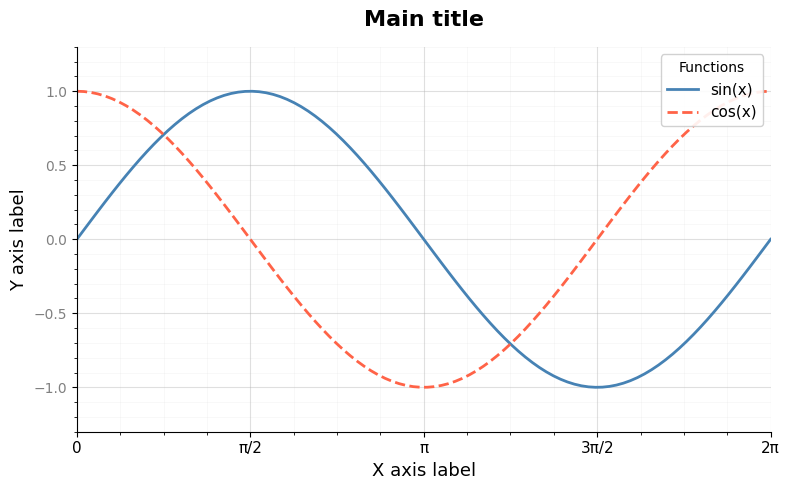

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, np.sin(x), color='steelblue', linewidth=2, label='sin(x)')
ax.plot(x, np.cos(x), color='tomato',    linewidth=2, label='cos(x)', linestyle='--')

# Title and labels with font control
ax.set_title('Main title', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('X axis label', fontsize=13)
ax.set_ylabel('Y axis label', fontsize=13)

# Tick customisation
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], fontsize=11)
ax.tick_params(axis='y', labelsize=10, labelcolor='gray')

# Legend — position options: 'best','upper right','lower left','center', etc.
ax.legend(loc='upper right', fontsize=11, framealpha=0.9,
          title='Functions', title_fontsize=10)

# Grid — major and minor
ax.grid(True, which='major', alpha=0.4, linewidth=0.8)
ax.minorticks_on()
ax.grid(True, which='minor', alpha=0.15, linewidth=0.4)

# Axis limits
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-1.3, 1.3)

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 10. Saving Figures

Save in any format: PNG (raster), PDF/SVG (vector, scalable), EPS.

Saved png: 40,663 bytes  at /tmp/tmpmojnl0r7.png


Saved pdf: 11,970 bytes  at /tmp/tmpgia5k412.pdf
Saved svg: 24,421 bytes  at /tmp/tmpgp6__pyy.svg


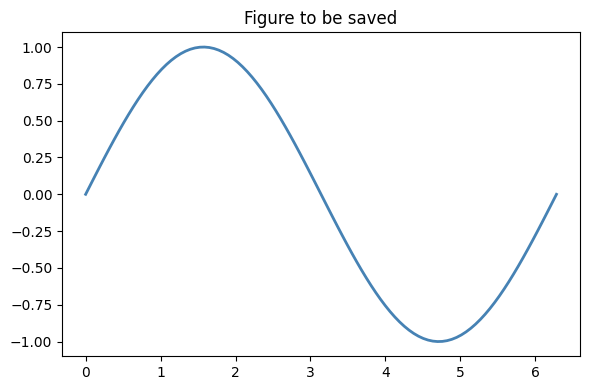


Common save options:
  dpi=150          — screen quality (72-100 for web, 300 for print)
  bbox_inches='tight' — no clipped labels
  transparent=True — transparent background (PNG/SVG)
  facecolor='white' — explicit white (override notebook defaults)



In [11]:
import tempfile, os

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.sin(x), color='steelblue', linewidth=2)
ax.set_title('Figure to be saved')
plt.tight_layout()

# Save options
for fmt in ['png', 'pdf', 'svg']:
    fpath = tempfile.mktemp(suffix=f'.{fmt}')
    fig.savefig(fpath,
                dpi=150,           # resolution (png only matters)
                bbox_inches='tight',  # avoids clipping
                facecolor='white') # explicit white background
    size = os.path.getsize(fpath)
    print(f'Saved {fmt}: {size:,} bytes  at {fpath}')
    os.unlink(fpath)

plt.show()

# Quick cheatsheet
print('''
Common save options:
  dpi=150          — screen quality (72-100 for web, 300 for print)
  bbox_inches='tight' — no clipped labels
  transparent=True — transparent background (PNG/SVG)
  facecolor='white' — explicit white (override notebook defaults)
''')


---
## 11. Seaborn Quick Reference

Seaborn wraps matplotlib with prettier defaults and higher-level APIs.

/tmp/ipykernel_49178/459541587.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_iris, x='species', y='petal length (cm)',
/tmp/ipykernel_49178/459541587.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_iris, x='species', y='sepal width (cm)',


/tmp/ipykernel_49178/459541587.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_iris, x='species', y='sepal length (cm)',


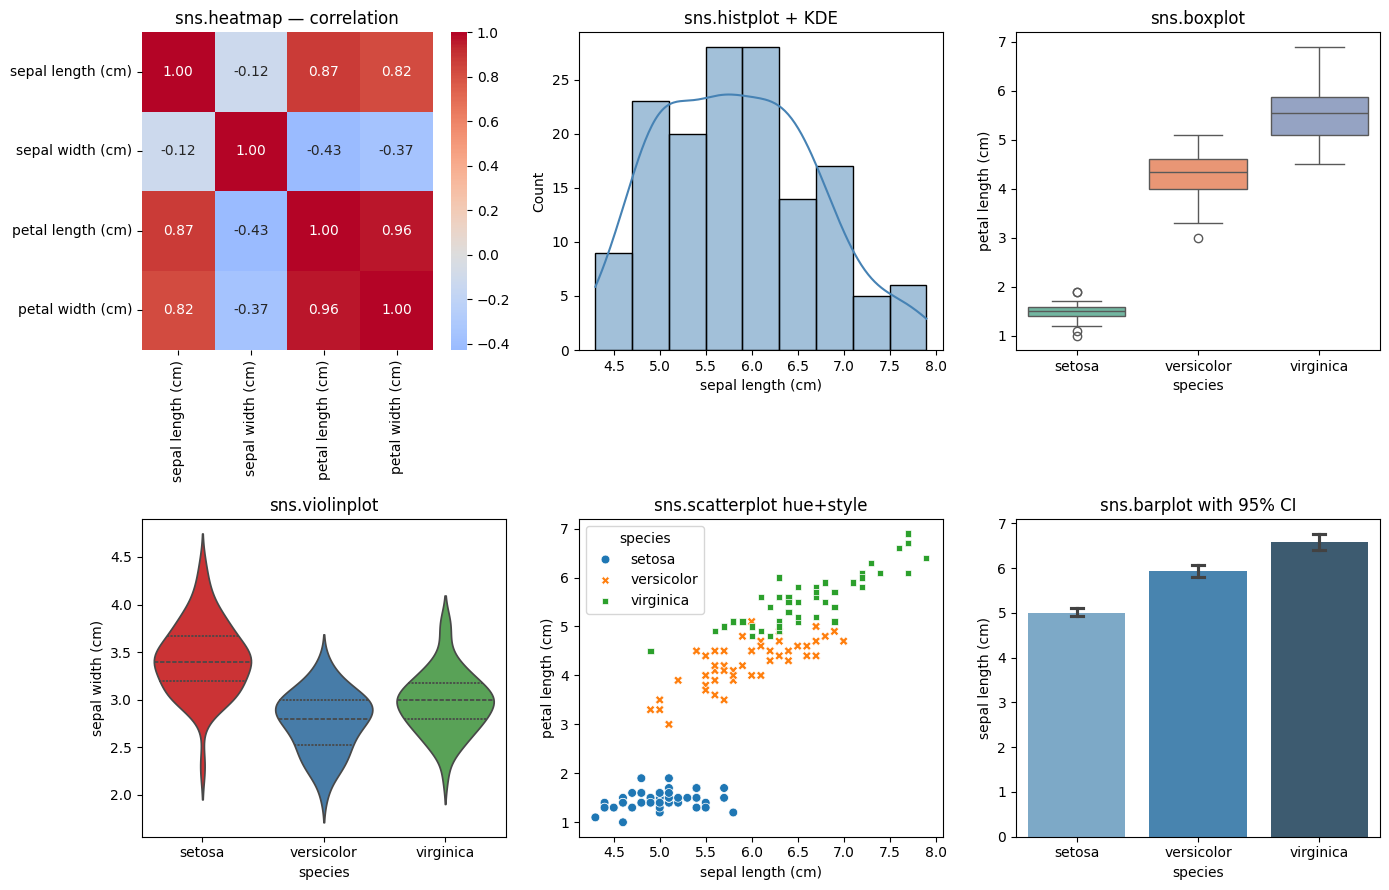

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# 1. Heatmap — correlation matrix
corr = df_iris.drop('species',axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0,0])
axes[0,0].set_title('sns.heatmap — correlation')

# 2. Pair plot (shown in separate figure)
# sns.pairplot(df_iris, hue='species')

# 3. Distribution plot
sns.histplot(df_iris['sepal length (cm)'], kde=True,
             color='steelblue', ax=axes[0,1])
axes[0,1].set_title('sns.histplot + KDE')

# 4. Box plot
sns.boxplot(data=df_iris, x='species', y='petal length (cm)',
            palette='Set2', ax=axes[0,2])
axes[0,2].set_title('sns.boxplot')

# 5. Violin
sns.violinplot(data=df_iris, x='species', y='sepal width (cm)',
               palette='Set1', inner='quartile', ax=axes[1,0])
axes[1,0].set_title('sns.violinplot')

# 6. Scatter (sns.scatterplot)
sns.scatterplot(data=df_iris, x='sepal length (cm)', y='petal length (cm)',
                hue='species', style='species', s=40, ax=axes[1,1])
axes[1,1].set_title('sns.scatterplot hue+style')

# 7. Bar plot with CI
sns.barplot(data=df_iris, x='species', y='sepal length (cm)',
            palette='Blues_d', capsize=0.1, ax=axes[1,2])
axes[1,2].set_title('sns.barplot with 95% CI')

plt.tight_layout()
plt.show()


---
## 12. ML-Specific Plots

Plots you'll use in almost every ML project.

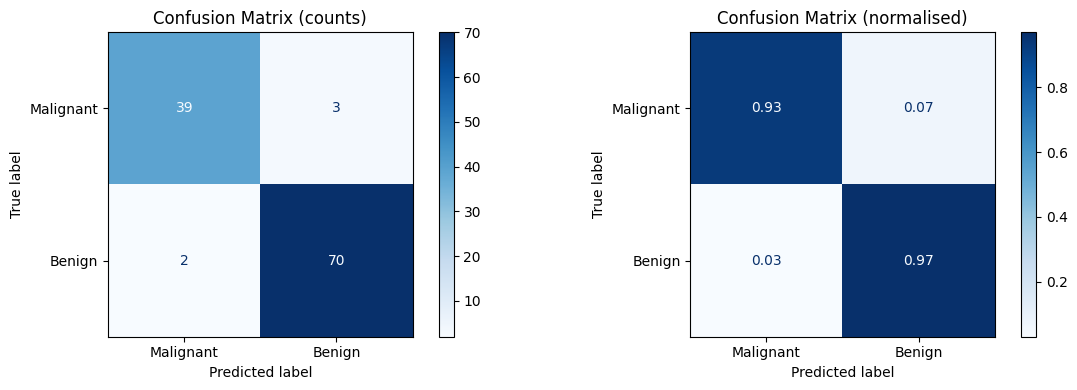

In [13]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.2,
                                            stratify=y_c, random_state=42)
pipe = Pipeline([('scl', StandardScaler()),
                 ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Malignant','Benign']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)')

# Normalised (proportions)
cm_norm = confusion_matrix(y_te, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Malignant','Benign']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix (normalised)')

plt.tight_layout()
plt.show()


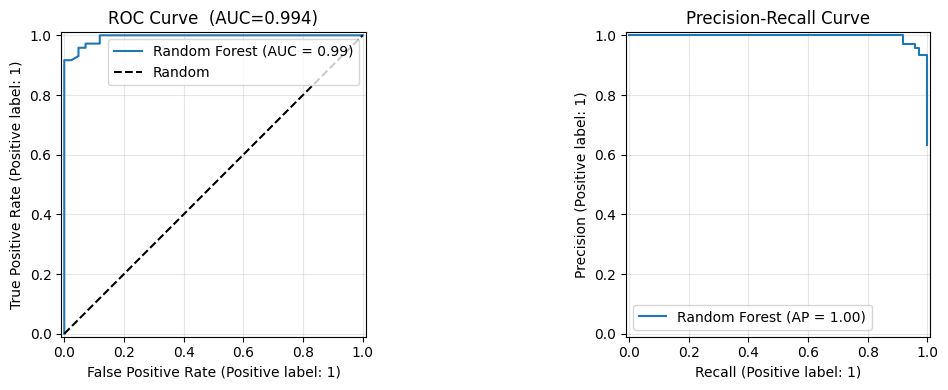

In [14]:
# ── ROC curve + Precision-Recall curve ────────────────────────────────────────
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score

y_proba = pipe.predict_proba(X_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_te, y_proba, ax=axes[0], name='Random Forest')
axes[0].plot([0,1],[0,1],'k--',label='Random')
axes[0].set_title(f'ROC Curve  (AUC={roc_auc_score(y_te, y_proba):.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_te, y_proba, ax=axes[1], name='Random Forest')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


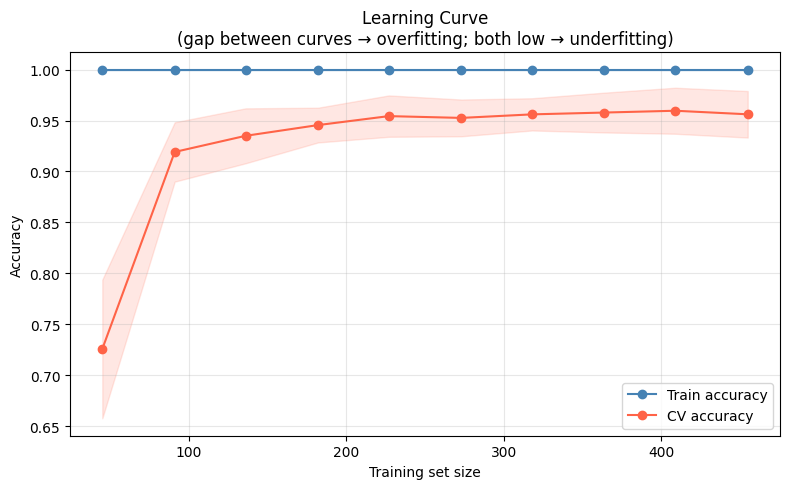

In [15]:
# ── Learning curve — diagnose overfitting / underfitting ─────────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_c, y_c, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train accuracy')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='CV accuracy')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='tomato')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve\n(gap between curves → overfitting; both low → underfitting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


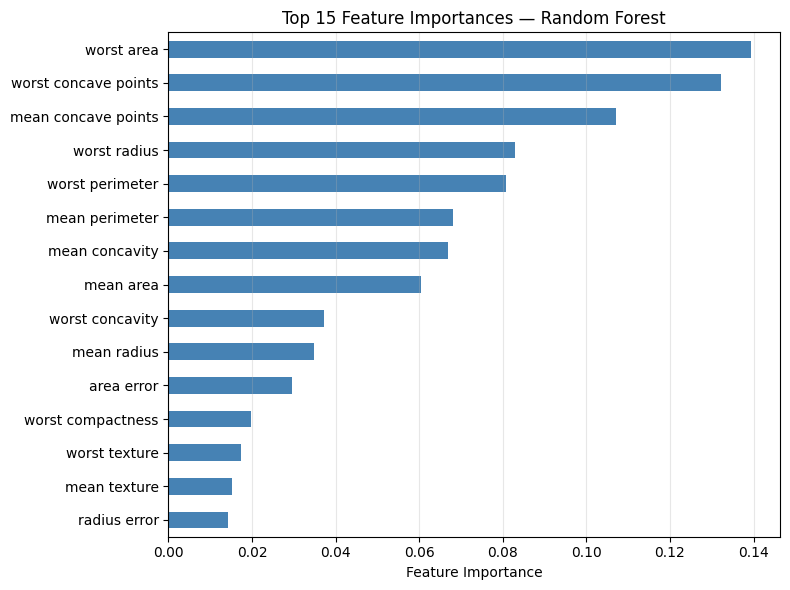

In [16]:
# ── Feature importance bar chart ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_c, y_c)
importances = pd.Series(rf.feature_importances_, index=cancer.feature_names)
importances = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


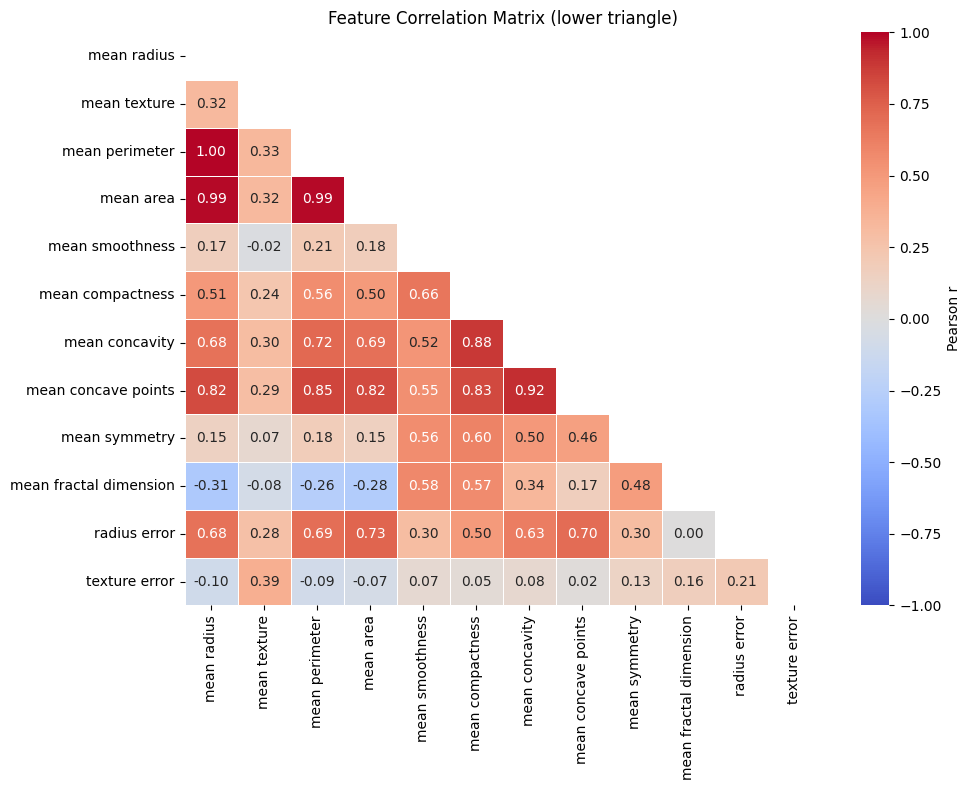

In [17]:
# ── Correlation heatmap with masking ──────────────────────────────────────────
import numpy as np
corr = X_c.iloc[:, :12].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()


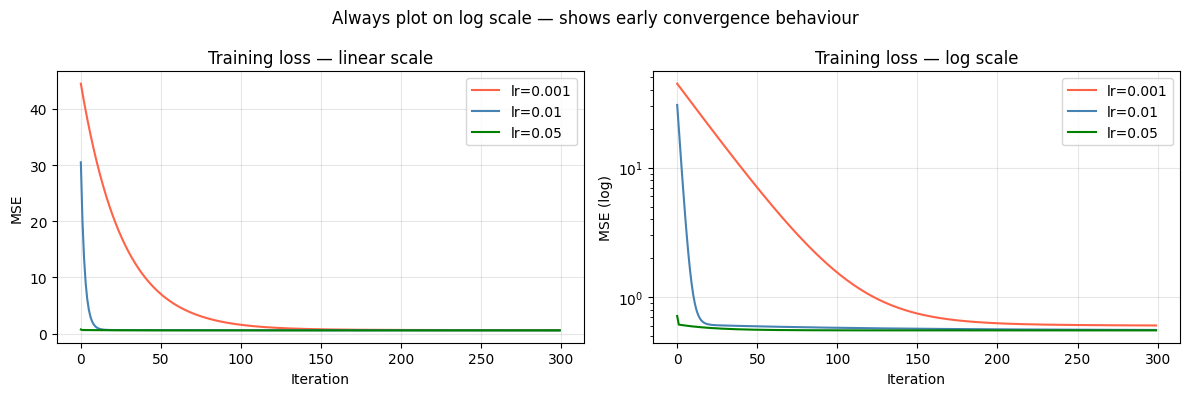

In [18]:
# ── Training loss curve (gradient descent) ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

rng2 = np.random.default_rng(0)
x1 = rng2.uniform(0, 5, 80)
y1 = 2*x1 + 1 + rng2.normal(0, 0.8, 80)
X1 = np.column_stack([np.ones_like(x1), x1])

losses = {}
for lr, color in [(0.001,'tomato'),(0.01,'steelblue'),(0.05,'green')]:
    w = np.zeros(2)
    loss_hist = []
    for _ in range(300):
        g = (2/len(y1)) * X1.T @ (X1 @ w - y1)
        w = w - lr * g
        loss_hist.append(np.mean((X1 @ w - y1)**2))
    losses[lr] = (loss_hist, color)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
for lr, (hist, color) in losses.items():
    axes[0].plot(hist, color=color, label=f'lr={lr}')
axes[0].set_title('Training loss — linear scale')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale (reveals early convergence detail)
for lr, (hist, color) in losses.items():
    axes[1].plot(hist, color=color, label=f'lr={lr}')
axes[1].set_yscale('log')
axes[1].set_title('Training loss — log scale')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE (log)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Always plot on log scale — shows early convergence behaviour')
plt.tight_layout()
plt.show()


---
## 13. Linear Regression — Closed-Form Visualization

Shows the OLS fit, individual residuals, and how the solution changes with Ridge / Lasso regularisation.


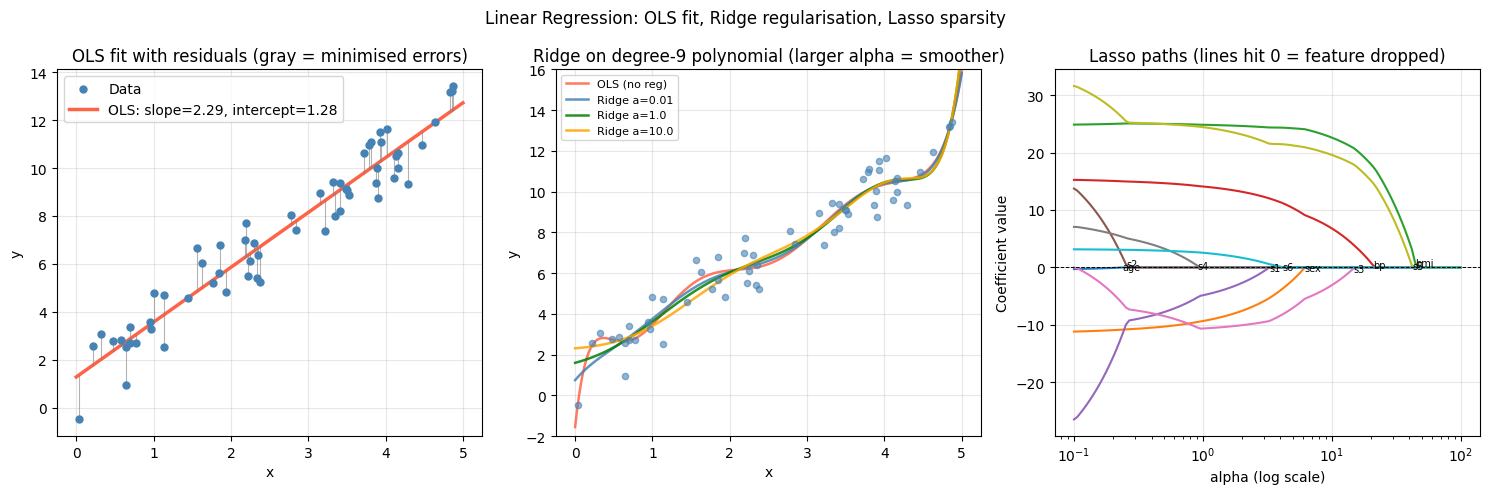

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso

rng = np.random.default_rng(42)
x   = rng.uniform(0, 5, 60)
y   = 2.3 * x + 1.5 + rng.normal(0, 1.2, 60)
X   = x.reshape(-1, 1)
x_line = np.linspace(0, 5, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. OLS fit + residuals
lr = LinearRegression().fit(X, y)
y_fit = lr.predict(X)

axes[0].scatter(x, y, color='steelblue', s=25, zorder=5, label='Data')
axes[0].plot(x_line, lr.predict(x_line), color='tomato', linewidth=2.5,
             label='OLS: slope={:.2f}, intercept={:.2f}'.format(lr.coef_[0], lr.intercept_))

for xi, yi, yf in zip(x, y, y_fit):
    axes[0].plot([xi, xi], [yi, yf], color='gray', linewidth=0.8, alpha=0.6)

axes[0].set_title('OLS fit with residuals (gray = minimised errors)')
axes[0].legend()
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# 2. Regularisation effect on degree-9 polynomial
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

degree = 9
X_poly_line = PolynomialFeatures(degree).fit_transform(x_line)

for alpha, color, label in [
        (0,    'tomato',    'OLS (no reg)'),
        (0.01, 'steelblue', 'Ridge a=0.01'),
        (1.0,  'green',     'Ridge a=1.0'),
        (10.0, 'orange',    'Ridge a=10.0')]:
    if alpha == 0:
        pipe = Pipeline([('poly', PolynomialFeatures(degree)), ('lr', LinearRegression())])
    else:
        pipe = Pipeline([('poly', PolynomialFeatures(degree)), ('lr', Ridge(alpha=alpha))])
    pipe.fit(X, y)
    axes[1].plot(x_line, pipe.predict(x_line), color=color, linewidth=1.8, label=label, alpha=0.85)

axes[1].scatter(x, y, color='steelblue', s=20, zorder=5, alpha=0.6)
axes[1].set_ylim(-2, 16)
axes[1].set_title('Ridge on degree-9 polynomial (larger alpha = smoother)')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

# 3. Lasso zeroes features (diabetes dataset)
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

Xd, yd = load_diabetes(return_X_y=True)
Xs = StandardScaler().fit_transform(Xd)
feat_names = load_diabetes().feature_names

alphas = np.logspace(-1, 2, 120)
coefs  = np.array([Lasso(alpha=a, max_iter=10000).fit(Xs, yd).coef_ for a in alphas])

for j in range(coefs.shape[1]):
    axes[2].plot(alphas, coefs[:, j], linewidth=1.5)
    nz = np.where(coefs[:, j] != 0)[0]
    if len(nz):
        axes[2].text(alphas[nz[-1]], coefs[nz[-1], j], feat_names[j], fontsize=7, va='center')

axes[2].set_xscale('log')
axes[2].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[2].set_xlabel('alpha (log scale)')
axes[2].set_ylabel('Coefficient value')
axes[2].set_title('Lasso paths (lines hit 0 = feature dropped)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Linear Regression: OLS fit, Ridge regularisation, Lasso sparsity', fontsize=12)
plt.tight_layout()
plt.show()


---
## 14. Gradient Descent — 3D Loss Surface & Contour Path

The MSE loss is a function of the two parameters (w₀=intercept, w₁=slope).
Plotting this surface as a 3D bowl and a 2D contour with the descent path overlaid
is the canonical way to understand what gradient descent is actually doing.


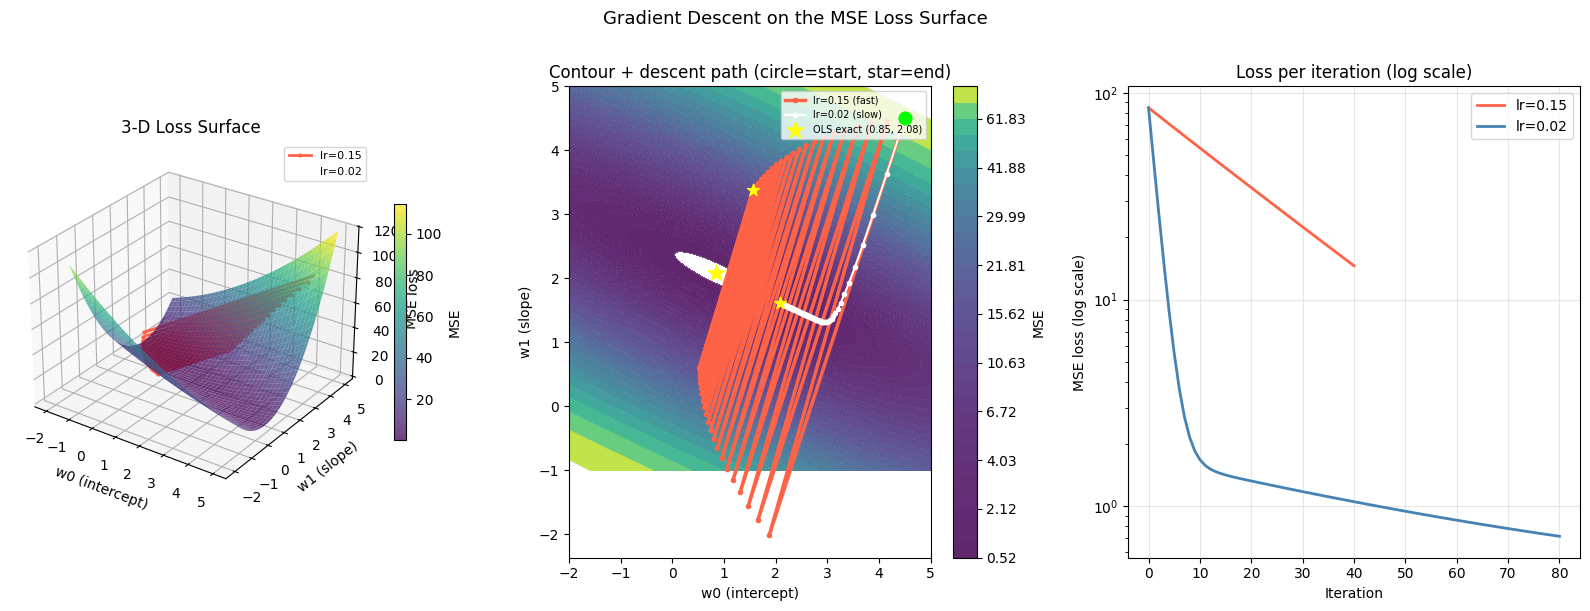

True:      w0=1.0, w1=2.0
OLS:       w0=0.8545, w1=2.0785
GD fast:   w0=1.5586, w1=3.3828
GD slow:   w0=2.0888, w1=1.6135


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rng = np.random.default_rng(0)
x_data = rng.uniform(0, 4, 50)
y_data = 2.0 * x_data + 1.0 + rng.normal(0, 0.6, 50)

def mse(w0, w1):
    return np.mean((w0 + w1 * x_data - y_data) ** 2)

# Build loss surface grid
w0_range = np.linspace(-2, 5, 120)
w1_range = np.linspace(-1, 5, 120)
W0, W1   = np.meshgrid(w0_range, w1_range)
Loss     = np.vectorize(mse)(W0, W1)

# Gradient descent paths
def gd(lr=0.05, n=80, start=(4.5, 4.5)):
    w = np.array(list(start), dtype=float)
    path = [w.copy()]
    for _ in range(n):
        y_hat = w[0] + w[1] * x_data
        err   = y_hat - y_data
        w    -= lr * np.array([2*err.mean(), 2*(err*x_data).mean()])
        path.append(w.copy())
    return np.array(path)

path_fast = gd(lr=0.15, n=40)
path_slow = gd(lr=0.02, n=80)

fig = plt.figure(figsize=(16, 6))

# --- 3-D surface ---
ax3d = fig.add_subplot(131, projection='3d')
surf = ax3d.plot_surface(W0, W1, Loss, cmap='viridis', alpha=0.75, rstride=3, cstride=3, linewidth=0)
fig.colorbar(surf, ax=ax3d, shrink=0.5, label='MSE')

for path, color, label in [(path_fast,'tomato','lr=0.15'),(path_slow,'white','lr=0.02')]:
    z_path = np.array([mse(p[0], p[1]) for p in path])
    ax3d.plot(path[:,0], path[:,1], z_path + 0.05, color=color,
              linewidth=2, marker='o', markersize=2, label=label)

ax3d.set_xlabel('w0 (intercept)')
ax3d.set_ylabel('w1 (slope)')
ax3d.set_zlabel('MSE loss')
ax3d.set_title('3-D Loss Surface')
ax3d.view_init(elev=28, azim=-55)
ax3d.legend(fontsize=8)

# --- Contour map + path ---
ax2d = fig.add_subplot(132)
levels = np.percentile(Loss, np.linspace(1, 99, 30))
cp = ax2d.contourf(W0, W1, Loss, levels=levels, cmap='viridis', alpha=0.85)
ax2d.contour(W0, W1, Loss, levels=levels, colors='white', linewidths=0.3, alpha=0.4)
plt.colorbar(cp, ax=ax2d, label='MSE')

for path, color, lw, label in [
        (path_fast, 'tomato', 2.5, 'lr=0.15 (fast)'),
        (path_slow, 'white',  1.5, 'lr=0.02 (slow)')]:
    ax2d.plot(path[:,0], path[:,1], color=color, linewidth=lw,
              marker='o', markersize=3, label=label, zorder=5)
    ax2d.scatter(*path[0],  color='lime',   s=80, zorder=6)
    ax2d.scatter(*path[-1], color='yellow', s=80, marker='*', zorder=6)

ax2d.set_xlabel('w0 (intercept)')
ax2d.set_ylabel('w1 (slope)')
ax2d.set_title('Contour + descent path (circle=start, star=end)')
ax2d.legend(fontsize=8, loc='upper right')

# --- OLS minimum ---
from numpy.linalg import lstsq
X_b = np.column_stack([np.ones_like(x_data), x_data])
w_ols, *_ = lstsq(X_b, y_data, rcond=None)
ax2d.scatter(w_ols[0], w_ols[1], color='yellow', s=150, marker='*',
             zorder=7, label='OLS exact ({:.2f}, {:.2f})'.format(w_ols[0], w_ols[1]))
ax2d.legend(fontsize=7, loc='upper right')

# --- Loss per iteration ---
ax_loss = fig.add_subplot(133)
for path, color, label in [(path_fast,'tomato','lr=0.15'),(path_slow,'steelblue','lr=0.02')]:
    losses = [mse(p[0], p[1]) for p in path]
    ax_loss.plot(losses, color=color, linewidth=2, label=label)

ax_loss.set_yscale('log')
ax_loss.set_xlabel('Iteration')
ax_loss.set_ylabel('MSE loss (log scale)')
ax_loss.set_title('Loss per iteration (log scale)')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.suptitle('Gradient Descent on the MSE Loss Surface', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('True:      w0=1.0, w1=2.0')
print('OLS:       w0={:.4f}, w1={:.4f}'.format(w_ols[0], w_ols[1]))
print('GD fast:   w0={:.4f}, w1={:.4f}'.format(path_fast[-1,0], path_fast[-1,1]))
print('GD slow:   w0={:.4f}, w1={:.4f}'.format(path_slow[-1,0], path_slow[-1,1]))


---
## 15. Gradient Descent — Learning Rate Effects (Side-by-Side Fits)

Watching the fit line evolve as training progresses shows *why* the loss surface matters.


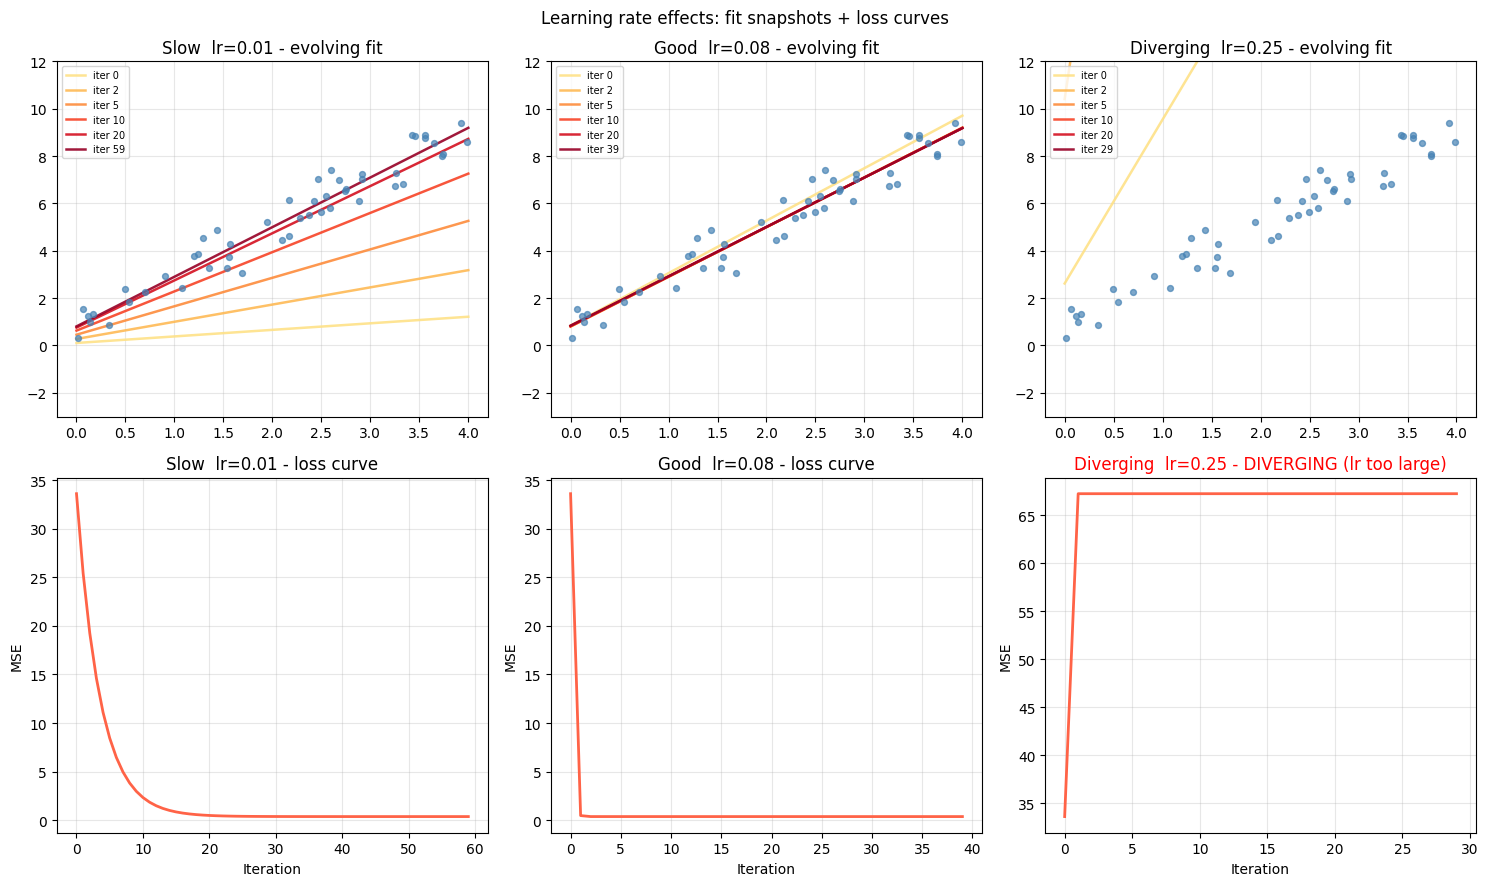

In [21]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x_d = rng.uniform(0, 4, 50)
y_d = 2.0 * x_d + 1.0 + rng.normal(0, 0.6, 50)
X_b = np.column_stack([np.ones_like(x_d), x_d])

def run_gd(lr, n_iter):
    w = np.array([0.0, 0.0])
    snapshots, losses = [], []
    for i in range(n_iter):
        err  = X_b @ w - y_d
        grad = (2 / len(y_d)) * X_b.T @ err
        w    = w - lr * grad
        losses.append(np.mean(err**2))
        if i in [0, 2, 5, 10, 20, n_iter-1]:
            snapshots.append((i, w.copy()))
    return snapshots, losses

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
x_line = np.linspace(0, 4, 100)
configs = [(0.01, 60, 'Slow  lr=0.01'), (0.08, 40, 'Good  lr=0.08'), (0.25, 30, 'Diverging  lr=0.25')]

for col, (lr, n_iter, title) in enumerate(configs):
    snapshots, losses = run_gd(lr, n_iter)

    ax = axes[0, col]
    ax.scatter(x_d, y_d, color='steelblue', s=18, zorder=5, alpha=0.7)
    cmap = plt.cm.YlOrRd
    for idx, (it, w) in enumerate(snapshots):
        c = cmap(0.2 + 0.75 * idx / max(len(snapshots)-1, 1))
        ax.plot(x_line, w[0] + w[1]*x_line, color=c, linewidth=1.8, alpha=0.9,
                label='iter {}'.format(it))
    ax.set_ylim(-3, 12)
    ax.set_title(title + ' - evolving fit')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, col]
    clipped = np.clip(losses, 0, losses[0]*2)
    ax2.plot(clipped, color='tomato', linewidth=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('MSE')
    if max(losses) > losses[0] * 1.5:
        ax2.set_title(title + ' - DIVERGING (lr too large)', color='red')
    else:
        ax2.set_title(title + ' - loss curve')
    ax2.grid(True, alpha=0.3)

plt.suptitle('Learning rate effects: fit snapshots + loss curves', fontsize=12)
plt.tight_layout()
plt.show()


---
## Quick Cheatsheet

```python
# ── Figure setup ─────────────────────────────────────────────
fig, ax   = plt.subplots(figsize=(8, 5))          # single
fig, axes = plt.subplots(2, 3, figsize=(14, 8))   # grid
fig.suptitle('Overall title')
plt.tight_layout()
plt.show()

# ── Plot types ───────────────────────────────────────────────
ax.plot(x, y, color='steelblue', linewidth=2, linestyle='--', label='name')
ax.scatter(x, y, c=colors, s=sizes, cmap='coolwarm', alpha=0.6)
ax.bar(categories, values, color='tomato', width=0.6, edgecolor='white')
ax.barh(categories, values)
ax.hist(data, bins=40, density=True, alpha=0.7, color='steelblue')
ax.boxplot(data_list, labels=['A','B'], patch_artist=True)

# ── Annotation ───────────────────────────────────────────────
ax.set_title('title', fontsize=14, fontweight='bold')
ax.set_xlabel('x label')
ax.set_ylabel('y label')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# ── Text & arrows ────────────────────────────────────────────
ax.text(x, y, 'label', ha='center', fontsize=10)
ax.annotate('text', xy=(x,y), xytext=(tx,ty),
            arrowprops=dict(arrowstyle='->', color='gray'))

# ── Spines ───────────────────────────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Colors ───────────────────────────────────────────────────
# Named: 'steelblue', 'tomato', 'green', 'orange'
# Hex:   '#2196F3'
# RGB:   (0.13, 0.59, 0.95)
# Colormap value: plt.cm.viridis(0.7)

# ── Save ─────────────────────────────────────────────────────
fig.savefig('plot.png', dpi=150, bbox_inches='tight', facecolor='white')
```
